In [26]:
import numpy as np
from scipy.optimize import milp, LinearConstraint, Bounds

# Ejercicio 1

En una imprenta se producen folletos y afiches. Cada folleto requiere 4 hojas de papel y cuesta $15. Cada afiche requiere 6 hojas de papel y cuesta $40. Se tienen las siguientes condiciones:

• No se pueden producir más de 90 impresos en total.

• Es necesario utilizar más de 390 hojas de papel.

• El costo total de producción no puede superar los $2000.

La ganancia es $25 por folleto y $50 por afiche. Se quiere determinar cuántos folletos y afiches deben producirse para maximizar la ganancia.

In [27]:

# Necesito encontrar la solución óptima

# La función objetivo a maximizar es
# z = 25x + 50y

# Las restricciones son:
# x+y≤90
# 4x+6y≥390, que se transforma en -4x-6y≤-390
# 15x+40y≤2000
# x,y≥0 

# coeficientes de la función objetivo (negativos porque linprog minimiza)
c = [-25, -50]

# coeficientes de las variables en las restricciones
A = [
    [1, 1],
    [4, 6],
    [15, 40]
]

# cotas superiores en las restricciones
bu = [90, np.inf, 2000] #bound upper :cota superior
bl = [-np.inf, 390, -np.inf] #np.inf : infinito

constraints = LinearConstraint(A, bl, bu) ##F,A>=0
bounds = Bounds([0, 0], [np.inf, np.inf]) #Acá le decimos que las variables son positivas.
res = milp(
    c=c,
    constraints=constraints,
    bounds=bounds,
    integrality=[0,0]
)
# Esto significa que para x,y si es 0 resuelve en continua, si es 1 resuelve en enteros

print("Estado:", res.message)
print("F =", -res.fun) #Ponemos un menos porque minimizó la función -F(x,y)
print("x =", res.x[0])
print("y =", res.x[1])
print(res.x)


Estado: Optimization terminated successfully. (HiGHS Status 7: Optimal)
F = 2900.0
x = 64.0
y = 26.0
[64. 26.]


## Interpretación de Resultados - Ejercicio 1
Para alcanzar la ganancia máxima de $2.900, la imprenta debe producir:
• 64 folletos (x) y 26 afiches (y)

## Región de Factibilidad


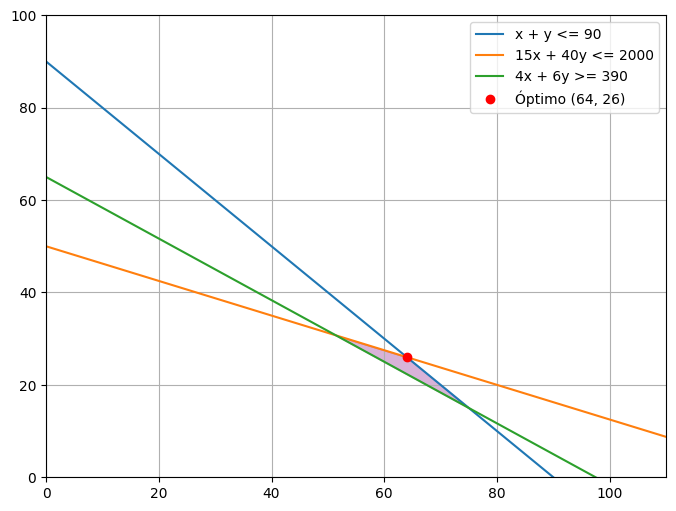

In [25]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 150, 400)

# Ecuaciones despejadas para y
y1 = 90 - x                # de x + y <= 90
y2 = (2000 - 15*x) / 40    # de 15x + 40y <= 2000
y3 = (390 - 4*x) / 6       # de 4x + 6y >= 390

plt.figure(figsize=(8,6))
plt.plot(x, y1, label='x + y <= 90')
plt.plot(x, y2, label='15x + 40y <= 2000')
plt.plot(x, y3, label='4x + 6y >= 390')

# Definir la región factible
y_min = np.maximum(y3, 0)
y_max = np.minimum(y1, y2)

plt.fill_between(x, y_min, y_max, where=(y_max > y_min), color='purple', alpha=0.3)

# Marcar el punto óptimo que te dio el código
plt.plot(64, 26, 'ro', label='Óptimo (64, 26)')

plt.xlim(0, 110); plt.ylim(0, 100)
plt.legend(); plt.grid(True)
plt.show()

# Ejercicio 2

Una pequeña fábrica produce tres tipos de cajas de regalo:

• x: cajas chicas

• y: cajas medianas

• z: cajas grandes

Cada tipo de caja requiere distintos recursos para su producción. Se dispone de una cantidad limitada de cartón y de cinta. Con un total de 8 unidades de cartón y 14 metros de cinta.

Caja Chica (x): 1 cartón + 1 metro de cinta.

Caja Mediana (y): 2 cartón + 1 metro de cinta.

Caja Grande (z): 3 cartón + 2 metros de cinta.

Además, la cantidad total de cajas producidas no puede superar las 12 unidades.
La ganancia por cada caja producida es de $3 para las cajas chicas, $5 para las medianas y $7 para las grandes.

Formulá un problema de programación lineal que permita maximizar la ganancia.

In [23]:

# Necesito encontrar la solución óptima

# La función objetivo a maximizar es 3x+5y+7z
# Las restricciones son:
# x+y+z≤12
# x+2y+3z≤8
# x+y+2z≤14
# x,y≥0 

B =[[1, 1, 1],
    [1,2,3],
    [1,1,2]]
bu = [12,8,14]
bl = [-np.inf,-np.inf,-np.inf]
constraints = LinearConstraint(B,bl,bu)
bounds = Bounds([0,0,0], [np.inf, np.inf, np.inf])

c=[-3,-5,-7]

res = milp(
    c=c,
    constraints=constraints, #restriccion = constraints
    bounds=bounds,
    integrality=[0,0,0]
)
# Esto significa que para x,y si es 0 resuelve en continua, si es 1 resuelve en enteros

print("Estado:", res.message)
print("F =", -res.fun) #Ponemos un menos porque minimizó la función -F(x,y)
print("x =", res.x[0])
print("y =", res.x[1])
print("z=", res.x[2])
print(res.x)



Estado: Optimization terminated successfully. (HiGHS Status 7: Optimal)
F = 24.0
x = 8.0
y = 0.0
z= 0.0
[8. 0. 0.]


## Interpretación de Resultados - Ejercicio 2
Para maximizar la ganancia total, que alcanza un valor de $24.0, la fábrica debe producir:

• 8 cajas chicas (x)

• 0 cajas medianas (y)

• 0 cajas grandes (z)

Insight hallado: Identifiqué que el cartón es el factor limitante (recurso agotado al 100%), ya que su escasez es lo único que impide incrementar la producción, a pesar de existir excedentes en cinta.

## Región de Factibilidad


![Región Factible 3D](region_fact_ej2.png)

<div style="border-top: 1px solid #ccc; margin-top: 20px; padding-top: 10px; font-family: sans-serif;">
    <p style="font-size: 0.9em; color: #555;">
        <b>Nota:</b> Gráfico realizado en <b>GeoGebra 3D</b>. 
        Debido a las limitantes del software para representar volúmenes de inecuaciones complejas, las restricciones se representaron mediante sus planos de frontera (igualdades):
    </p>
    <ul style="font-size: 0.85em; list-style: none;">
        <li><span style="color: #E67E22;">●</span> x + y + z = 12 (Restricción original: <= 12)</li>
        <li><span style="color: #3498DB;">●</span> x + 2y + 3z = 8 (Restricción original: <= 8)</li>
        <li><span style="color: #9B59B6;">●</span> x + y + 2z = 14 (Restricción original: <= 14)</li>
    </ul>
    <p style="font-size: 0.85em; font-style: italic; color: #777;">
        La región de factibilidad es el espacio encerrado por debajo de estos planos en el primer octante.
    </p>
</div>
En el gráfico 3D se observa que el punto óptimo (8, 0, 0) se encuentra sobre el plano de restricción de cartón, confirmando que este es el recurso que limita la producción máxima.